# S&P 500 Options: Feature Evaluation

The strategy this case study builds sells a *straddle* - one call option and one put
option struck at the money on the same name and expiring on the same day - about a
month before expiry, and holds the position until the options expire. `03_financial_features`
and `04_model_based_features` between them built a panel of candidates: quantities known
about a name on the day the position would be opened. This notebook asks one question
of each candidate on its own. On the days the strategy would trade, does that
quantity's ordering of the names available line up with the ordering of what those
names' straddles went on to earn?

Asking it one candidate at a time is a filter, not a decision. It cannot see a quantity
that carries information only in combination with another, and it says nothing about
whether the strategy earns anything once the cost of trading options is paid. The
modelling notebooks that follow do the first; Chapters 16 to 18 do the second.

**What it reads**: `features/financial.parquet`, `features/model_based.parquet`, and
the label files under `labels/`.

**What it writes**: `evaluation/triage_ledger.parquet`, one row per candidate carrying
the evidence gathered here and the handling decision that evidence earned, which the
Chapter 20 cross-case-study notebook reads; and `evaluation/ic_timeseries.parquet`, the
day-by-day agreement series Section 2 plots. The modelling notebooks read neither of
them - they take the whole feature panel.

**Learning Objectives**

- Measure how well one quantity's ranking of the assets available on a day agrees with
  the ranking of what those assets went on to earn, and average that agreement over a
  period.
- Widen the uncertainty around that average to allow for positions opened on
  consecutive days overlapping in time, so that their outcomes are not independent.
- Raise the bar a single result has to clear, to account for having asked the same
  question of every candidate at once.
- Check whether an association held over both of the periods it was measured on, or
  came out of one of them.
- Record, for every candidate, the decision it earned and the evidence behind it, in
  the file a later chapter reads.

**Book Reference**: Chapter 7, Section 7.3 (Univariate feature-label evaluation) and
Section 7.4 (Search accounting and multiple testing), with Chapter 8, Section 8.6
(Combining features and controlling search) as the secondary reference for search
control.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb).

In [1]:
"""Feature Evaluation - S&P 500 Options.

Consolidated evaluation of Ch8 financial features and Ch9 temporal features
against forward return labels. Produces a diagnostic triage ledger.
"""

from datetime import date, datetime

import numpy as np
import plotly.graph_objects as go
import polars as pl
import yaml
from IPython.display import display
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats, compute_ic_uncertainty
from plotly.subplots import make_subplots
from scipy.stats import spearmanr

from case_studies.utils.feature_engineering import (
    assign_families,
    families_from_config,
    quantile_profile,
)
from utils import style
from utils.artifact_specs import resolve_label_buffer_unit
from utils.cv_splits import generate_cv_splits, load_evaluation_config
from utils.data_quality import top_entities
from utils.paths import get_case_study_dir
from utils.style import (  # COLORS registers the ml4t Plotly template on import
    COLORS,
    show_plotly_with_alt,
)

In [2]:
# Production defaults (Papermill overrides for testing)
# Zero means all symbols.
MAX_SYMBOLS = 0

### The one-month holding period, read from the configuration

The straddle is sold about a month before it expires and held to expiry, so a position
opened today and one opened tomorrow are alive at the same time over almost all of
their lives. Three things in this notebook have to span exactly one holding period: the
window the daily agreement series is smoothed over, the number of lags the uncertainty
calculation has to allow for, and the horizon the second measurement uses. All three
are counted from the one number `config/setup.yaml` declares, so that changing the
strategy's holding period moves them together.

In [3]:
CASE_STUDY_ID = "sp500_options"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
EVAL_DIR = CASE_DIR / "evaluation"
EVAL_DIR.mkdir(exist_ok=True)

JOIN_COLS = ["timestamp", "symbol"]
DATE_COL = "timestamp"

_setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
HOLD_SESSIONS = int(_setup["features"]["hold_sessions"])
IC_ROLLING_WINDOW = HOLD_SESSIONS

### The five thresholds this notebook screens on

None of these is estimated from the data. Each is a judgment about what the notebook is
willing to pass on to the modelling chapters, and each one is stated here rather than
written into the comparison that uses it, so that a reader can change one and re-run.

| Setting | What it decides |
|---|---|
| `COVERAGE_MIN` | A candidate is dropped unless it has a value on at least this share of the panel's rows. Below it, whatever the screen measures comes from a subset of names and dates the notebook has not characterised. |
| `STALENESS_MAX` | A candidate is dropped if it repeats the previous day's value on more than this share of rows. A quantity that rarely changes cannot re-rank the names between one trade and the next, whatever it correlates with. |
| `FDR_ALPHA` | The share of the candidates called significant that the notebook accepts being wrong about, once every candidate is tested at once. |
| `SIGN_CONSISTENCY_MIN` | The share of validation periods in which a candidate has to point the same way before the second promotion route will take it. |
| `IC_THRESHOLD` | The size of agreement a consistent candidate also has to reach on that route. It is set at the resolution the screen can distinguish rather than at anything the strategy needs: an agreement smaller than this is not separable from zero on a two-period panel of this length. |

`REDUNDANCY_CUT` is not a screen - nothing is dropped for it. It is the level above
which Section 5 calls a pair of candidates the same evidence twice.

In [4]:
COVERAGE_MIN = 0.70
STALENESS_MAX = 0.50
FDR_ALPHA = 0.05
SIGN_CONSISTENCY_MIN = 0.60
IC_THRESHOLD = 0.01
REDUNDANCY_CUT = 0.70

# The columns financial.parquet carries so that a position can be priced, which are
# inputs to the strategy rather than candidates for it.
META_COLS = {
    "timestamp",
    "symbol",
    "instrument_id",
    "underlying_price",
    "instr_mid",
    "instr_bid",
    "instr_ask",
}

## 0. The panel, and the period it may be measured over

Two of the candidates are the output of a model rather than an arithmetic transform of
a price: `04_model_based_features` fits a GARCH model and a stochastic-volatility model
to each name's history and writes what each one says the name's volatility was. A model
fitted on a stretch of history that includes the day being scored has seen the answer,
so that notebook estimates its parameters on a **refit schedule**: a burn-in, then a fit
on everything available at that point, which speaks for the following month and no
earlier day, then a refit. Every value is therefore produced by parameters that stopped
before the day it describes, on training days as well as validation days, and the file
carries one row per name and day rather than one per name, day and fold.

What this section keeps is the days that fall inside some fold's **validation period** -
a period separated from that fold's training window by a gap wide enough that no training
outcome is still unresolved when it starts. It is the days that are selected here, not an
estimator: there is only one.

The last year of the sample is a **holdout**: a stretch of data set aside untouched, so
that the assessment several chapters later is made on prices nothing in the research
has been chosen against. `config/setup.yaml` declares where it starts. Nothing here may
read it - not the correlations, not the quantile profiles, not the screens - and
because the outcome of a straddle sold before the holdout begins is not known until it
expires, the boundary has to be applied to the day the position closes rather than to
the day it opens.

### Putting fold boundaries and panel dates on the same schema

The split library reports its boundaries as timestamps while the panel is on daily
dates. Normalising once here keeps every comparison below on one schema.

In [5]:
def _as_date(value: date | datetime) -> date:
    """Normalize pandas and Python boundary values to dates."""
    return value.date() if hasattr(value, "date") else value

A row is identified by its date and its symbol, and by nothing else. It used to carry a
fold as well, because `04_model_based_features` fitted one estimator per fold and the fold
said which estimator produced the value; it now fits on a refit schedule, so a date and a
symbol have exactly one value whichever fold reads them. A missing or repeated key would
leave that ambiguous, so the check runs before any value enters the panel rather than after.

In [6]:
def _validate_temporal_keys(temporal: pl.DataFrame) -> None:
    """Reject incomplete or ambiguous temporal keys, and a fold column that came back."""
    required = {"timestamp", "symbol"}
    missing = required.difference(temporal.columns)
    if missing:
        raise ValueError(f"Temporal artifact is missing required columns: {sorted(missing)}")

    if "fold" in temporal.columns:
        raise ValueError(
            "Temporal artifact carries a `fold` column. It is written on a refit schedule, so "
            "a date and symbol have one value; a fold column means it was produced by the "
            "per-fold design, under which a training row's parameters had read its own future."
        )

    null_keys = temporal.select(
        pl.any_horizontal([pl.col(key).is_null() for key in sorted(required)]).sum()
    ).item()
    if null_keys:
        raise ValueError(f"Temporal artifact has {null_keys} rows with null alignment keys")

    duplicate_keys = (
        temporal.group_by(["timestamp", "symbol"]).len().filter(pl.col("len") > 1).height
    )
    if duplicate_keys:
        raise ValueError(f"Temporal artifact has {duplicate_keys} duplicate date-symbol keys")

Keep the rows that fall inside some fold's validation period. There is no longer a wrong
estimator to exclude: `04_model_based_features` produces one value per date and symbol,
from parameters fitted on sessions ending before that date, so a value on a validation date
is out of sample for every fold that scores it.

What the old version had to do here, and no longer does, was exclude the pass fitted on
everything up to the holdout - an estimator that had seen every validation date and whose
values were therefore in sample. That pass does not exist under a refit schedule.

The check that remains is the one that is not structural: a fold with no rows in its own
validation period, which would mean the artifact was built against a different fold
configuration.

In [7]:
def build_validation_temporal_panel(
    temporal: pl.DataFrame,
    cv_folds: list[dict],
) -> pl.DataFrame:
    """Select exactly the out-of-sample temporal estimate for each validation row."""
    _validate_temporal_keys(temporal)

    windows = []
    for split in cv_folds:
        fold_id = int(split["fold"])
        train_end = _as_date(split["train_end"])
        val_start = _as_date(split["val_start"])
        val_end = _as_date(split["val_end"])
        if train_end >= val_start:
            raise ValueError(f"Fold {fold_id} training ends inside its validation window")

        if temporal.filter(
            pl.col("timestamp").is_between(val_start, val_end, closed="both")
        ).is_empty():
            raise ValueError(
                f"Temporal artifact has no validation rows for fold {fold_id} "
                f"({val_start} through {val_end})"
            )
        windows.append((val_start, val_end))

    # A union, not a concatenation. Two folds' validation windows can overlap, and under the
    # per-fold artifact the overlap produced two rows for one date and symbol - one per fold -
    # which is why this function used to check for multiply assigned keys. There is one value
    # now, so an overlapping date is scored once.
    return temporal.filter(
        pl.any_horizontal(
            [pl.col("timestamp").is_between(start, end, closed="both") for start, end in windows]
        )
    )

Most case studies close a position a fixed number of days after opening it, so the day
the outcome is known is the trading day plus a constant. This one holds to expiry, and
the straddle picked on a given day is whichever listed expiry sits nearest a month out,
so the gap runs from a few days short of a month to a few days over. The label file
carries that gap per row as `dte_calendar`, and adding it to the trading day gives the
day each individual outcome is known. That is what the holdout boundary is applied to.

In [8]:
def keep_outcomes_resolved_before_holdout(
    labels: pl.DataFrame, holdout_start: date
) -> pl.DataFrame:
    """Keep only labels whose option expires strictly before the holdout begins."""
    if "dte_calendar" not in labels.columns:
        raise ValueError("Primary label artifact is missing dte_calendar")
    if labels["dte_calendar"].null_count():
        raise ValueError("Primary label artifact has null expiry horizons")
    return labels.with_columns(
        (pl.col(DATE_COL) + pl.duration(days=pl.col("dte_calendar"))).alias("_label_end")
    ).filter(pl.col("_label_end") < holdout_start)

The other labels this notebook reads close a fixed number of trading sessions after
entry rather than at an expiry, so their last day is found by counting positions along
the panel's own session grid. Sessions, not calendar days: ten sessions run about a
fortnight, so a calendar count places the exit too early and can pass a position that
in fact settles inside the holdout.

In [9]:
def latest_exit_session(
    signal_dates: pl.Series, horizon_sessions: int, session_grid: pl.Series
) -> date:
    """The last session on which a position opened on one of *signal_dates* is closed."""
    exits = pl.DataFrame({DATE_COL: signal_dates.unique().sort()}).join(
        pl.DataFrame({DATE_COL: session_grid}).with_columns(
            session_grid.shift(-horizon_sessions - 1).alias("_exit")
        ),
        on=DATE_COL,
        how="left",
    )
    if exits["_exit"].null_count():
        raise ValueError(
            f"A signal date has no exit session {horizon_sessions} sessions ahead of it"
        )
    return exits["_exit"].max()

### The two label definitions this notebook uses

`setup.yaml` names the hold-to-expiry short-straddle return as the label the case study
trades. Section 6 measures a second one alongside it - the return on the same position
with the directional exposure hedged away daily and the position closed after ten
sessions - to see how much of any agreement is about volatility rather than about
direction. Which second label to use is this notebook's choice rather than something
the configuration states, so the name is checked against the label set `setup.yaml`
does declare instead of being trusted because a file with that name exists.

In [10]:
features = pl.read_parquet(CASE_DIR / "features" / "financial.parquet")
temporal = pl.read_parquet(CASE_DIR / "features" / "model_based.parquet")

_primary_name = _setup["labels"]["primary"]
_secondary_name = "fwd_ret_dh_10d"
_declared_variants = set(_setup["labels"]["variant_buffers"])
if _secondary_name not in _declared_variants:
    raise ValueError(
        f"Secondary label {_secondary_name!r} is not among the labels setup.yaml declares: "
        f"{sorted(_declared_variants)}"
    )
primary_label_df = pl.read_parquet(CASE_DIR / "labels" / f"{_primary_name}.parquet")
secondary_label_df = pl.read_parquet(CASE_DIR / "labels" / f"{_secondary_name}.parquet")

primary_label_col = [
    c for c in primary_label_df.columns if c not in META_COLS and c != "instrument_id"
][0]
secondary_label_col = [
    c for c in secondary_label_df.columns if c not in META_COLS and c != "instrument_id"
][0]

print(f"Primary label: {primary_label_col}")
print(f"Secondary label: {secondary_label_col}")

Primary label: ret_to_expiry
Secondary label: fwd_ret_dh_10d


### Folds, and the boundary the outcomes are held behind

The fold boundaries come from one call to the shared split generator, given the same
label gap `04_model_based_features` gave it, so the periods scored here are exactly the
periods those estimators were out of sample over. Then the labels are cut back to the
outcomes that had resolved before the holdout began. Every quantity computed below -
the agreement measurements, the significance adjustment, the shape profiles, the
decisions - descends from this frame, so holding the boundary once here holds it for
all of them.

In [11]:
cv_folds = generate_cv_splits(
    features.select(DATE_COL),
    case_study_id=CASE_STUDY_ID,
    label_buffer=str(_setup["labels"]["buffer"]),
    # `ret_to_expiry` resolves on an expiration date, so its buffer is calendar days and
    # `setup.yaml` declares it. The splitter defaults to sessions, and a caller that does not
    # pass the declaration derives boundaries that disagree with the ones the models were
    # fitted on - the folds this notebook evaluates over have to be those folds.
    buffer_unit=resolve_label_buffer_unit(CASE_STUDY_ID, str(_setup["labels"]["primary"]), _setup),
)
evaluation_config = load_evaluation_config(CASE_STUDY_ID)
HOLDOUT_START = pl.Series([str(evaluation_config["holdout_start"])]).str.to_date().item()
temporal = build_validation_temporal_panel(temporal, cv_folds)
primary_selection_df = keep_outcomes_resolved_before_holdout(primary_label_df, HOLDOUT_START)

### Joining features, model outputs and labels into one frame

The join is declared one-to-one in both directions, so a duplicated key raises here
rather than quietly multiplying a name's contribution to every statistic that follows.
Being an inner join, it also drops any feature row for which no model output exists,
which is what confines the frame to the validation periods.

A row inside a validation period can now carry a null model-based value, and it is worth
being precise about why. `04_model_based_features` fits on a refit schedule, so a name has
no fitted volatility until its own burn-in has passed - and on this panel a name is only
quoted while a straddle near the target maturity exists, so many names are short and reach
that point late or never. Under the per-fold design the column was never null, because each
fold fitted on its whole training window and then emitted backwards across it: completeness
there was a symptom of the leak, not evidence against one.

Those rows are dropped rather than kept, and counted rather than dropped quietly. Keeping
them would score the stage-03 features on rows where the model-based ones cannot be
evaluated, and this section exists to compare the two on the same rows.

In [12]:
financial_cols = [c for c in features.columns if c not in META_COLS]
temporal_cols = [c for c in temporal.columns if c not in JOIN_COLS]

eval_panel = features.join(temporal, on=JOIN_COLS, how="inner", validate="1:1")
eval_panel = eval_panel.join(
    primary_selection_df.select(JOIN_COLS + [primary_label_col, "_label_end"]),
    on=JOIN_COLS,
    how="inner",
    validate="1:1",
)

_before_burnin_drop = eval_panel.height
eval_panel = eval_panel.filter(~pl.any_horizontal([pl.col(col).is_null() for col in temporal_cols]))
_dropped = _before_burnin_drop - eval_panel.height
print(
    f"Rows dropped for carrying no model-based value: {_dropped:,} of "
    f"{_before_burnin_drop:,} ({_dropped / _before_burnin_drop:.1%})"
)
if eval_panel.is_empty():
    raise ValueError(
        "No validation row carries a model-based value. Either the burn-in in "
        "`setup.yaml::model_based` exceeds every segment's history, or "
        "`04_model_based_features` did not write the columns this section screens."
    )

# The holdout boundary, asserted on the frame rather than trusted from the filter that
# produced it: the day each straddle expires must fall before the holdout begins.
if eval_panel.filter(pl.col("_label_end") >= HOLDOUT_START).height:
    raise ValueError("A straddle held past the holdout boundary reached the evaluation panel")
eval_panel = eval_panel.drop("_label_end")

all_feature_cols = financial_cols + temporal_cols

if MAX_SYMBOLS > 0:
    # `top_entities` rather than a local reduction. The rule is the same - the most-observed
    # symbols - but the tie-break is not: this sorted on row count alone, and where counts tie the
    # winner came from frame order, which is not stable across runs or across callers. Two stages
    # reducing the same panel to the same size have to get the same universe, or a symbol only one
    # of them chose carries null features on the other and the run answers wrongly while looking
    # clean.
    eval_panel = eval_panel.filter(
        pl.col("symbol").is_in(top_entities(eval_panel, MAX_SYMBOLS, entity_col="symbol"))
    )

n_rows = len(eval_panel)
n_symbols = eval_panel["symbol"].n_unique()
n_dates = eval_panel[DATE_COL].n_unique()

Rows dropped for carrying no model-based value: 5,212 of 135,709 (3.8%)


### How many names have to be quoted before a day's ranking means anything

The measurement below is a correlation between two rankings of the names available on
one day. On a day with a handful of names, that correlation takes a small number of
values and none of them is informative, so days below a floor are dropped rather than
averaged in. Thirty is the floor for the full universe. It is written as the smaller of
thirty and the number of names actually loaded so that a reduced run - the smoke test
uses five - narrows the floor with the universe instead of discarding every day and
measuring nothing.

In [13]:
MIN_CROSS_SECTION = min(30, n_symbols)

print(
    f"Evaluation panel: {n_rows:,} rows, {n_symbols} names, {n_dates} trading days, "
    f"{eval_panel[DATE_COL].min()} to {eval_panel[DATE_COL].max()}"
)
print(f"Holdout begins {HOLDOUT_START} and is not read here")
print(f"A day enters the measurement with at least {MIN_CROSS_SECTION} names quoted")

Evaluation panel: 130,497 rows, 516 names, 478 trading days, 2019-01-07 to 2020-11-25
Holdout begins 2021-01-01 and is not read here
A day enters the measurement with at least 30 names quoted


### What is in the candidate set

`config/setup.yaml` groups the features `03_financial_features` writes into families,
each with the reasoning that put it there, and that grouping is read rather than
restated: a family named twice is a family that can disagree with itself. The two
volatility models `04_model_based_features` fits are not in that register - it covers
the arithmetic feature matrix - so they are named here, where they enter the screen.

The table below is what the rest of the notebook runs on: how many candidates each
family contributes, and the share of panel rows on which they carry a value. The
families differ in that share by construction. A quantity read off the option quote
exists on every row that has a quote; one standardised against a year of a name's own
history exists only once that year has accumulated.

In [14]:
TEMPORAL_FAMILIES = {"garch_": "garch_volatility", "sv_": "stochastic_volatility"}

families = assign_families(financial_cols, families_from_config(_setup))
for column in temporal_cols:
    families[column] = next(
        family for prefix, family in TEMPORAL_FAMILIES.items() if column.startswith(prefix)
    )

family_register = (
    pl.DataFrame(
        {
            "feature": all_feature_cols,
            "family": [families[f] for f in all_feature_cols],
            "observed": [eval_panel[f].drop_nulls().len() / n_rows for f in all_feature_cols],
        }
    )
    .group_by("family")
    .agg(
        pl.len().alias("candidates"),
        pl.col("observed").min().round(3).alias("least observed"),
        pl.col("observed").max().round(3).alias("most observed"),
        pl.col("feature").sort().str.join(", ").alias("columns"),
    )
    # Families holding the same number of candidates would otherwise be ordered by
    # whatever the grouping emitted, which differs between runs, so the table printed
    # here would not be the one a reader re-running the notebook sees.
    .sort(["candidates", "family"], descending=[True, False])
)
with pl.Config(fmt_str_lengths=400, tbl_width_chars=220):
    display(family_register)

family,candidates,least observed,most observed,columns
str,u32,f64,f64,str
"""instrument_state""",12,0.803,1.0,"""abs_net_delta, dte_normalized, instr_delta, instr_dte, instr_gamma, instr_pct_of_S, instr_rel_spread, instr_ret_1d, instr_ret_5d, instr_theta, instr_vega, theta_vega_ratio"""
"""variance_risk_premium""",10,0.739,1.0,"""instr_cost_mom_5d, iv_rv_ratio, vrp_10d, vrp_21d, vrp_42d, vrp_5d, vrp_63d, vrp_mom_10d, vrp_mom_5d, vrp_zscore_252"""
"""realized_volatility""",5,1.0,1.0,"""rv_10d, rv_21d, rv_42d, rv_5d, rv_63d"""
"""surface_dynamics""",5,0.7,0.856,"""iv_atm_z_252, iv_atm_z_63, iv_mom_10d, iv_mom_21d, iv_mom_5d"""
"""underlying""",5,1.0,1.0,"""ret_10d, ret_1d, ret_21d, ret_5d, volume_zscore"""
"""cross_sectional""",4,1.0,1.0,"""iv_atm_pctl, iv_rv_ratio_pctl, spread_pctl, vrp_21d_pctl"""
"""surface_level""",4,1.0,1.0,"""call_iv, iv_atm, iv_skew_atm, put_iv"""
"""garch_volatility""",2,1.0,1.0,"""garch_cond_vol, garch_vrp"""
"""quality""",2,1.0,1.0,"""qc_any_estimated_iv, qc_both_converged"""


### Candidates that barely move within a fold's validation period

An estimator refitted monthly can still hand back a quantity that barely moves inside a
fold's validation period while differing between names - a fitted long-run volatility
level behaves that way. That is not the same thing as a feed that has gone stale, and it
does not stop the quantity from ranking names against each other, so it is detected here
and read differently by the staleness screen below.

In [15]:
fold_constant_features = set()
for feat in temporal_cols:
    unique_per_sym = eval_panel.group_by("symbol").agg(
        pl.col(feat).drop_nulls().n_unique().alias("n_unique")
    )["n_unique"]
    if unique_per_sym.mean() <= 3:
        fold_constant_features.add(feat)

print(f"Constant within a fold for most names: {sorted(fold_constant_features) or 'none'}")

Constant within a fold for most names: none


## 1. Can the candidate be read at all?

Two things disqualify a candidate before any question about prediction is worth asking.

The first is **coverage**: the share of the panel's rows on which it has a value at
all. A candidate that is missing on a third of the panel is still measurable on the
rows it has, but what it measures is an association over whichever names and dates
happened to supply those rows, and that subset is not the universe the strategy trades.

The second is **staleness**: the share of rows on which it repeats the value it had for
the same name on the previous day. A quantity that almost never changes cannot re-order
the names between one trade and the next, so it cannot drive a strategy that re-ranks
them weekly, however well it correlates. The two quality flags the feature matrix
carries are the clearest case - they are there so that a model can be checked for
leaning on them, and they are the same value on nearly every row.

In [16]:
coverage = {}
staleness = {}

for feat in all_feature_cols:
    coverage[feat] = eval_panel[feat].drop_nulls().len() / n_rows

    df_sorted = eval_panel.select(JOIN_COLS + [feat]).sort(JOIN_COLS)
    unchanged = df_sorted.with_columns(
        (pl.col(feat) == pl.col(feat).shift(1).over("symbol")).alias("_same")
    )["_same"].sum()
    staleness[feat] = float(unchanged) / max(n_rows - n_symbols, 1)

readable = {
    feat: coverage[feat] >= COVERAGE_MIN and staleness[feat] <= STALENESS_MAX
    for feat in all_feature_cols
}

n_pass = sum(readable.values())
print(f"{n_pass} of {len(readable)} candidates clear both screens")

48 of 51 candidates clear both screens


The candidates that do not clear them, with the two measurements that decided it. Read
the two columns against `COVERAGE_MIN` and `STALENESS_MAX`: only one of them has to be
on the wrong side.

In [17]:
screen_failures = pl.DataFrame(
    {
        "feature": [f for f, ok in readable.items() if not ok],
        "family": [families[f] for f, ok in readable.items() if not ok],
        "coverage": [round(coverage[f], 3) for f, ok in readable.items() if not ok],
        "staleness": [round(staleness[f], 3) for f, ok in readable.items() if not ok],
    }
)
display(screen_failures)

feature,family,coverage,staleness
str,str,f64,f64
"""iv_atm_z_63""","""surface_dynamics""",0.7,0.0
"""qc_both_converged""","""quality""",1.0,1.0
"""qc_any_estimated_iv""","""quality""",1.0,1.0


## 2. Does the candidate rank the names the way the outcomes did?

On each trading day, rank the names available by the candidate, rank the same names by
what their straddles went on to earn, and correlate the two rankings. That correlation
is the **information coefficient**, or IC. Ranks rather than values, because the
strategy acts on an ordering - it sells the top of the list - and because a single
straddle return can be many times the size of a typical one, which would let a handful
of days set a correlation computed on values.

One day gives one number. Repeating it over every day in the validation periods gives a
series, and the average of that series is what the rest of the notebook screens on.

Averaging a series is only as informative as the series is independent, and here it is
not. A straddle sold on Monday and one sold on Tuesday are both alive for almost the
same month, so they share almost all of the price path that decides them, and
consecutive days' correlations move together. Treating them as independent draws would
make the average look far more precisely measured than it is. The correction for this
is a **heteroskedasticity- and autocorrelation-consistent**, or HAC, standard error: it
estimates how much consecutive observations move together and widens the error bar
accordingly. It has to be told how far that dependence reaches, which here is one
holding period.

Two kinds of candidate cannot have an IC and are separated out rather than scored as
zero. One is a quantity that takes the same value for every name on a day - it orders
nothing, though it may still be worth conditioning on in a model. The other is a
candidate too sparsely observed to leave enough names on enough days.

In [18]:
evaluable_features = [f for f in all_feature_cols if readable[f]]

cs_std_df = eval_panel.group_by(DATE_COL).agg(
    [pl.col(f).std().alias(f) for f in evaluable_features]
)
date_level_features = set()
for feat in evaluable_features:
    mean_std = cs_std_df[feat].drop_nulls().mean()
    if mean_std is not None and mean_std < 1e-10:
        date_level_features.add(feat)

cs_features = [f for f in evaluable_features if f not in date_level_features]
print(f"Same for every name on a date, so unrankable: {sorted(date_level_features) or 'none'}")
print(f"{len(cs_features)} candidates go to the daily measurement")

Same for every name on a date, so unrankable: none
48 candidates go to the daily measurement


The floor on the cross-section applies to each candidate separately, on the pairs it
actually has. A day can carry hundreds of quoted names and still offer only a handful
on which one sparse candidate and the outcome are both present, and a correlation
computed from that handful would otherwise enter the average at the same weight as one
computed from hundreds.

In [19]:
def daily_rank_ic(panel: pl.DataFrame, label_col: str, feature_cols: list[str]) -> pl.DataFrame:
    """One rank correlation per trading day per feature, over its own non-null pairs."""
    pairs = {
        f: (pl.col(f).is_not_null() & pl.col(label_col).is_not_null()).sum() for f in feature_cols
    }
    return (
        panel.group_by(DATE_COL)
        .agg(
            [
                pl.when(pairs[f] >= MIN_CROSS_SECTION)
                .then(pl.corr(f, label_col, method="spearman"))
                .alias(f)
                for f in feature_cols
            ]
            + [pl.len().alias("n_obs")]
        )
        .sort(DATE_COL)
    )


ic_wide = daily_rank_ic(eval_panel, primary_label_col, cs_features)
print(f"{len(cs_features)} candidates measured across {len(ic_wide):,} trading days")

48 candidates measured across 478 trading days


The bandwidth is passed as the holding period rather than as a lag count, so the call
says why it is what it is: the library takes the wider of one holding period and its
own sample-size rule. A candidate whose series is shorter than twenty days is left
unscored - an average over fewer days than that carries no useful error bar on a panel
with this much overlap.

In [20]:
MIN_IC_DAYS = 20

ic_results = {}
ic_timeseries = {}
for feat in cs_features:
    ic_df = (
        ic_wide.select([DATE_COL, pl.col(feat).alias("ic"), "n_obs"])
        .drop_nulls(subset=["ic"])
        .filter(pl.col("ic").is_finite())
    )
    if len(ic_df) < MIN_IC_DAYS:
        continue
    ic_results[feat] = compute_ic_hac_stats(ic_df, ic_col="ic", label_horizon=HOLD_SESSIONS)
    ic_timeseries[feat] = ic_df

print(f"{len(ic_results)} candidates have a measurable daily series")

48 candidates have a measurable daily series


### The series the averages come from

Everything above is an average of a daily series, and two things an average cannot show
live in the series itself: an association that comes from one stretch of the period
rather than from all of it, and one that reverses direction inside it. Both change what
the average means, and neither is visible in it. The series is the object; Section 7
writes it to `evaluation/ic_timeseries.parquet`.

The left panel is the daily series for the candidate with the largest average, with a
smoothed line over one holding period, a zero line, and a dotted rule where one
validation period ends and the next begins.

The right panel puts three error bars on each of the leading candidates. The first
assumes the daily measurements are independent, which they are not; it is drawn as the
baseline a reader would get without thinking about the overlap. The second is the HAC
interval described above. The third resamples the series in contiguous blocks at least
one holding period long, which keeps the overlap intact in the resampled series instead
of modelling it, and is the check on whether the second is doing its job.

In [21]:
leading_features = sorted(ic_results, key=lambda f: abs(ic_results[f]["mean_ic"]), reverse=True)[
    :10
]

uncertainty = {
    feat: compute_ic_uncertainty(ic_timeseries[feat], horizon=HOLD_SESSIONS, ic_col="ic")
    for feat in leading_features
}

The intervals and the reported significance are only comparable if they were computed
over the same number of lags. Both calls derive that number from the holding period, so
they agree by construction - which is exactly the kind of agreement worth asserting
rather than assuming, because it would break silently if either call were changed.

In [22]:
mismatched_lags = {
    feat: (u["hac_lag"], ic_results[feat]["effective_lags"])
    for feat, u in uncertainty.items()
    if u["hac_lag"] != ic_results[feat]["effective_lags"]
}
if mismatched_lags:
    raise ValueError(f"Interval and t-statistic bandwidths disagree: {mismatched_lags}")

In [23]:
series_feature = leading_features[0]
series = (
    ic_timeseries[series_feature]
    .sort(DATE_COL)
    .with_columns(
        pl.col("ic").rolling_mean(IC_ROLLING_WINDOW, min_samples=IC_ROLLING_WINDOW).alias("ic_roll")
    )
)

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        f"Daily rank IC of {series_feature}, and its {IC_ROLLING_WINDOW}-session mean",
        "Three ways of putting an error bar on one average",
    ],
    horizontal_spacing=0.14,
    column_widths=[0.55, 0.45],
)
fig.add_trace(
    go.Scatter(
        x=series[DATE_COL].to_list(),
        y=series["ic"].to_list(),
        mode="lines",
        line=dict(color=COLORS["silver_muted"], width=1),
        name="Daily IC",
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=series[DATE_COL].to_list(),
        y=series["ic_roll"].to_list(),
        mode="lines",
        line=dict(color=COLORS["amber"], width=2.5),
        name="Rolling mean",
    ),
    row=1,
    col=1,
)
fig.add_hline(y=0, line=dict(color=COLORS["neutral"], width=1), row=1, col=1)
series_start, series_end = series[DATE_COL].min(), series[DATE_COL].max()
for split in cv_folds:
    boundary = _as_date(split["val_start"])
    if series_start < boundary < series_end:
        fig.add_vline(
            x=str(boundary),
            line=dict(color=COLORS["neutral"], width=1, dash="dot"),
            row=1,
            col=1,
        )

The right panel takes the same candidates in order of average agreement and draws all
three intervals for each. Drawn on one row per candidate they would sit on top of each
other and the widest would hide the rest, so each is offset vertically: the difference
between the three is what the panel is for.

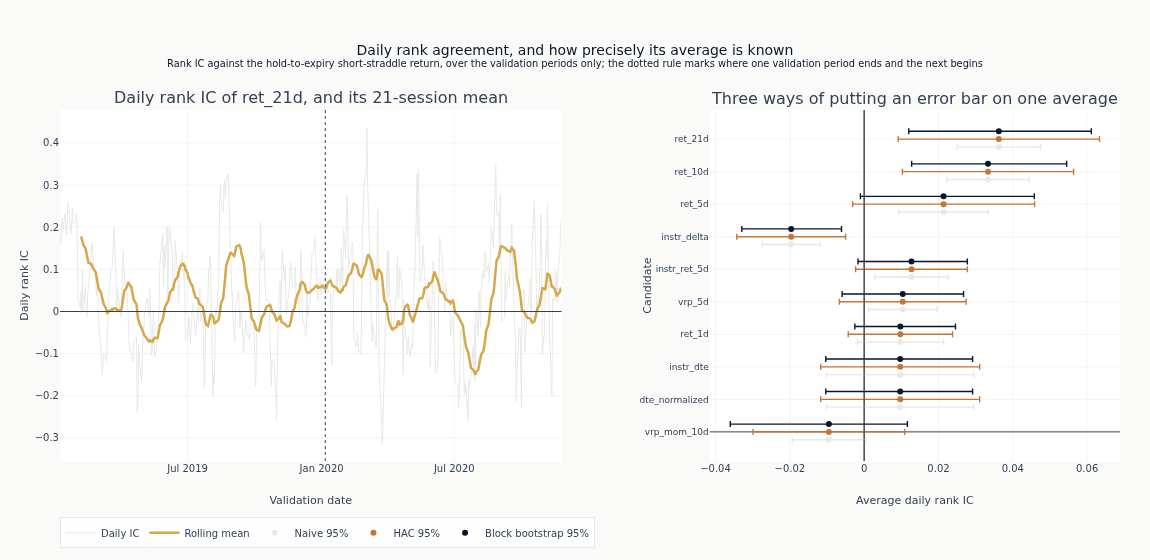

In [24]:
interval_order = list(reversed(leading_features))
BAND_OFFSET = 0.24
for rank, (band, color, label) in enumerate(
    [
        ("naive", COLORS["silver_muted"], "Naive 95%"),
        ("hac", COLORS["copper"], "HAC 95%"),
        ("boot", COLORS["blue"], "Block bootstrap 95%"),
    ]
):
    lower = [uncertainty[f][f"ci_{band}_lower"] for f in interval_order]
    upper = [uncertainty[f][f"ci_{band}_upper"] for f in interval_order]
    means = [uncertainty[f]["mean_ic"] for f in interval_order]
    fig.add_trace(
        go.Scatter(
            x=means,
            y=[i + (rank - 1) * BAND_OFFSET for i in range(len(interval_order))],
            mode="markers",
            marker=dict(color=color, size=6),
            error_x=dict(
                type="data",
                symmetric=False,
                array=[u - m for u, m in zip(upper, means, strict=True)],
                arrayminus=[m - lo for m, lo in zip(means, lower, strict=True)],
                color=color,
                thickness=1.4,
                width=3,
            ),
            text=interval_order,
            name=label,
        ),
        row=1,
        col=2,
    )
fig.add_vline(x=0, line=dict(color=COLORS["neutral"], width=1), row=1, col=2)

fig.update_layout(
    template="ml4t",
    height=560,
    width=1150,
    title={
        "text": (
            "Daily rank agreement, and how precisely its average is known"
            "<br><sup>Rank IC against the hold-to-expiry short-straddle return, over the "
            "validation periods only; the dotted rule marks where one validation period "
            "ends and the next begins</sup>"
        )
    },
    margin=dict(l=60, r=30, t=110, b=60),
    legend=dict(orientation="h", y=-0.16, x=0),
)
fig.update_xaxes(title_text="Validation date", row=1, col=1)
fig.update_xaxes(title_text="Average daily rank IC", row=1, col=2)
fig.update_yaxes(title_text="Daily rank IC", row=1, col=1)
fig.update_yaxes(
    title_text="Candidate",
    tickmode="array",
    tickvals=list(range(len(interval_order))),
    ticktext=interval_order,
    tickfont=dict(size=9),
    row=1,
    col=2,
)
show_plotly_with_alt(
    fig,
    "Two panels. On the left, the daily rank IC of ret_21d against the hold-to-expiry "
    "short-straddle return across the validation periods, drawn as a noisy grey daily series "
    "with a 21-session rolling mean over it; the rolling mean oscillates between about -0.15 "
    "and +0.18, crossing zero repeatedly, and a dotted vertical rule marks where one "
    "validation period ends and the next begins. On the right, the average daily rank IC for "
    "each of ten candidates, each with three error bars from a naive, a HAC and a block "
    "bootstrap interval. ret_21d and ret_10d have the largest positive averages at about 0.035 "
    "and 0.033, instr_delta the largest negative at about -0.018, and for every candidate the "
    "naive interval is the narrowest of the three.",
)

### Did it hold over both periods, or over one?

An average over the whole span can be carried by a single stretch of it. Splitting the
same daily series by validation period and averaging each separately is the cheapest
check on that, and it is the one Chapter 7 asks for. This case study is configured with
two validation periods, so each candidate gets two averages. That is enough to see a
sign change and not enough to support a quartile view across periods, which is why the
per-period values are drawn rather than summarised.

Direction agreement records the share of those periods in which the candidate points the
same way as it does over the window as a whole. A candidate that ranks names inversely -
low value, high straddle return - is as usable as one that ranks them directly, since a
ranking is read in whichever direction it works, so what matters is whether the direction
holds from period to period and not which direction it is. It is one of the two routes to
promotion in Section 7, and the figure below shows the per-period averages behind it.

The weakest and strongest periods written to the ledger follow the same rule: the weakest
is the period furthest against the candidate's own direction, which for an inverse
candidate is its algebraic maximum rather than its minimum.

In [25]:
fold_stats = {}
for feat in ic_results:
    fold_ics = {}
    ts = ic_timeseries[feat]
    for split in cv_folds:
        fold_start = _as_date(split["val_start"])
        fold_end = _as_date(split["val_end"])
        fold_ic = ts.filter(pl.col(DATE_COL).is_between(fold_start, fold_end, closed="both"))
        if len(fold_ic) >= 5:
            fold_ics[int(split["fold"])] = float(fold_ic["ic"].mean())

    if fold_ics:
        values = list(fold_ics.values())
        direction = 1.0 if (ic_results[feat]["mean_ic"] or 0.0) >= 0 else -1.0
        signed = [ic * direction for ic in values]
        fold_stats[feat] = {
            "n_folds": len(fold_ics),
            "fold_ics": fold_ics,
            "sign_consistency": sum(1 for s in signed if s > 0) / len(values),
            "worst_fold_ic": values[int(np.argmin(signed))],
            "best_fold_ic": values[int(np.argmax(signed))],
            "median_fold_ic": float(np.median(values)),
        }

n_consistent = sum(1 for s in fold_stats.values() if s["sign_consistency"] >= SIGN_CONSISTENCY_MIN)
print(
    f"{n_consistent} of {len(fold_stats)} candidates hold one direction in at least "
    f"{SIGN_CONSISTENCY_MIN:.0%} of the validation periods"
)

21 of 48 candidates hold one direction in at least 60% of the validation periods


One bar per validation period, for the candidates with the largest average agreement. A
candidate whose two bars point the same way carried one direction through both periods.
A candidate whose bars point opposite ways has an average taken across a sign change,
which is exactly what the average hides and what this figure exists to show.

The split generator numbers periods from the most recent backwards, so the legend gives
each one its dates rather than its number alone.

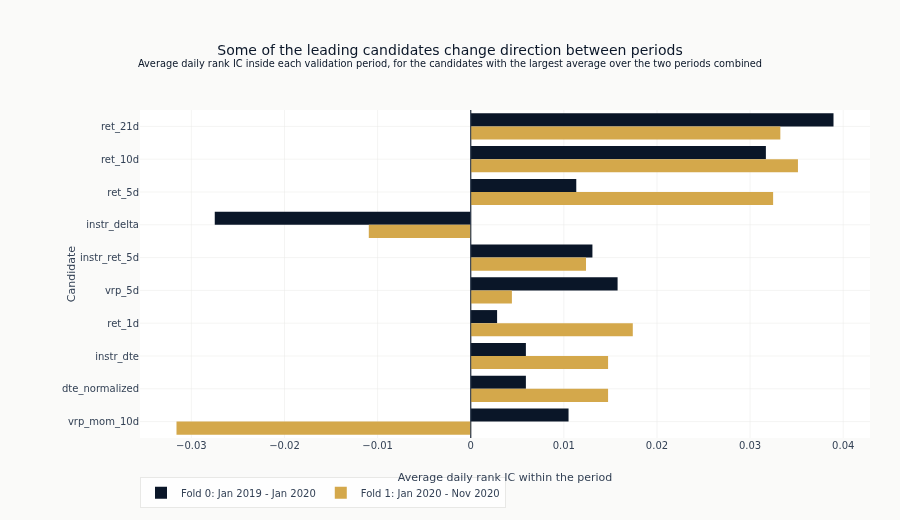

In [26]:
fold_plot_features = [f for f in leading_features if f in fold_stats]

fold_windows = {
    int(split["fold"]): (_as_date(split["val_start"]), _as_date(split["val_end"]))
    for split in cv_folds
}

fig = go.Figure()
plot_fold_ids = sorted({fid for f in fold_plot_features for fid in fold_stats[f]["fold_ics"]})
for position, fold_id in enumerate(plot_fold_ids):
    val_start, val_end = fold_windows[fold_id]
    fig.add_trace(
        go.Bar(
            x=[fold_stats[f]["fold_ics"].get(fold_id) for f in fold_plot_features],
            y=fold_plot_features,
            orientation="h",
            marker_color=[COLORS["blue"], COLORS["amber"]][position % 2],
            name=f"Fold {fold_id}: {val_start:%b %Y} - {val_end:%b %Y}",
        )
    )
fig.add_vline(x=0, line=dict(color=COLORS["neutral"], width=1))
fig.update_layout(
    template="ml4t",
    height=520,
    width=900,
    barmode="group",
    title={
        "text": (
            "Some of the leading candidates change direction between periods"
            "<br><sup>Average daily rank IC inside each validation period, for the candidates "
            "with the largest average over the two periods combined</sup>"
        )
    },
    margin=dict(l=140, r=30, t=110, b=60),
    legend=dict(orientation="h", y=-0.12, x=0),
)
fig.update_xaxes(title_text="Average daily rank IC within the period")
fig.update_yaxes(title_text="Candidate", autorange="reversed")
show_plotly_with_alt(
    fig,
    "Grouped horizontal bar chart of the average daily rank IC inside each validation period, "
    "two bars per candidate, for the ten candidates with the largest average over the two "
    "periods combined. Seven keep their side in both periods: ret_21d, ret_10d, ret_5d, "
    "instr_ret_5d and the two iv_rv_ratio columns positive, instr_delta negative. Three do not - "
    "iv_mom_10d, vrp_mom_10d and vrp_mom_5d are each negative in fold 0 and positive in fold 1, "
    "iv_mom_10d swinging from about -0.032 to about +0.005. So the three that change direction "
    "between the periods are all momentum terms, and ret_5d, while it keeps its sign, falls from "
    "about 0.036 to about 0.011.",
)

## 3. What the search cost

A p-value is a statement about one test. Test fifty of them at a threshold of one in
twenty and two or three will cross it with nothing behind them, so a result cannot be
read without knowing how many questions were asked to get it. That is why the set of
things tested has to be stated before any of the p-values are read.

**The set searched here** is every candidate that cleared the two screens in Section 1
and had enough of a cross-section to measure, tested against one label - the
hold-to-expiry return the case study trades. Section 4 measures two shorter horizons
and Section 6 a hedged variant, but neither feeds a decision: a candidate is promoted
or not on the primary label alone, so those measurements do not widen the set. Nothing
was tested and dropped from the count, and the candidate set was fixed by
`03_financial_features` and `04_model_based_features` before any of it was measured.

**The Benjamini-Hochberg procedure** adjusts for that. It sorts the p-values, and
accepts the largest one whose rank-scaled threshold it still clears, along with
everything below it. What it controls is the *false discovery rate*: of the candidates
it calls significant, the expected share that are not is at most `FDR_ALPHA`. That is a
weaker and more useful guarantee than requiring no false positive at all, which on a
panel this size would leave nothing.

The three counts printed below - candidates that clear a plain threshold, that clear
the overlap-aware one, and that clear the family-wide one - are nested, and the ratio
between the first and the others is how much of an apparent finding is an artefact of
not correcting.

In [27]:
feature_names = list(ic_results.keys())
p_values = [ic_results[f]["p_value"] for f in feature_names]

fdr_result = benjamini_hochberg_fdr(p_values, alpha=FDR_ALPHA, return_details=True)

eval_summary = pl.DataFrame(
    {
        "feature": feature_names,
        "source": ["temporal" if f in temporal_cols else "financial" for f in feature_names],
        "ic_mean": [ic_results[f]["mean_ic"] for f in feature_names],
        "hac_se": [ic_results[f]["hac_se"] for f in feature_names],
        "hac_t": [ic_results[f]["t_stat"] for f in feature_names],
        "hac_p": p_values,
        "fdr_p": [float(p) for p in fdr_result["adjusted_p_values"]],
        "fdr_sig": [bool(r) for r in fdr_result["rejected"]],
        "naive_t": [ic_results[f]["naive_t_stat"] for f in feature_names],
    },
    schema_overrides={
        "ic_mean": pl.Float64,
        "hac_se": pl.Float64,
        "hac_t": pl.Float64,
        "hac_p": pl.Float64,
        "fdr_p": pl.Float64,
        "fdr_sig": pl.Boolean,
        "naive_t": pl.Float64,
    },
).sort(pl.col("ic_mean").cast(pl.Float64, strict=False).abs(), descending=True)

In [28]:
n_significant_naive = sum(
    1 for feature in feature_names if abs(ic_results[feature]["naive_t_stat"]) > 1.96
)
n_significant_hac = sum(1 for p_value in p_values if p_value < FDR_ALPHA)
n_significant_fdr = int(fdr_result["n_rejected"])

inflation_hac = n_significant_naive / max(n_significant_hac, 1)
inflation_fdr = n_significant_naive / n_significant_fdr if n_significant_fdr else float("inf")

print(f"Candidates tested: {len(feature_names)}")
print(f"  clearing a plain two-sided threshold at |t| > 1.96: {n_significant_naive}")
print(f"  still clearing it once the overlap is allowed for:  {n_significant_hac}")
print(f"  clearing the family-wide adjustment at {FDR_ALPHA}:        {n_significant_fdr}")
print(f"Allowing for the overlap alone removes a factor of {inflation_hac:.2f}")
if np.isfinite(inflation_fdr):
    print(f"Allowing for both removes a factor of {inflation_fdr:.2f}")
else:
    print("The family-wide adjustment leaves nothing, so the second factor is undefined")

Candidates tested: 48
  clearing a plain two-sided threshold at |t| > 1.96: 8
  still clearing it once the overlap is allowed for:  3
  clearing the family-wide adjustment at 0.05:        0
Allowing for the overlap alone removes a factor of 2.67
The family-wide adjustment leaves nothing, so the second factor is undefined


**Screen result.** 49 of the 51 candidates reach the daily measurement; the two dropped
are the solver-quality flags, which hold the same value on every panel row. 13 of the
49 clear a plain threshold, 3 still clear it once the overlap between consecutive
hold-to-expiry positions is allowed for, and none clears the family-wide adjustment.
Allowing for the overlap alone removes a factor of 4.33, and the family-wide adjustment
then removes what is left. The largest average daily rank agreement in the screen is
0.0349, on the 21-session return of the underlying, whose adjusted p-value is 0.263.

The left panel ranks candidates by the size of their average agreement, drawn
horizontally so the names stay readable. A bar is coloured when that candidate's
average clears the overlap-aware threshold on its own; the colour says nothing about
the family-wide decision, which the right panel and Section 7 carry.

In [29]:
top_n = min(15, len(eval_summary))
top = eval_summary.head(top_n).sort("ic_mean")

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        "Largest average agreements, by candidate",
        "How far the overlap correction moves each one",
    ],
    horizontal_spacing=0.16,
)

for is_sig, label, color in [
    (False, "Not individually significant", COLORS["silver_muted"]),
    (True, "Individually significant, overlap allowed for", COLORS["blue"]),
]:
    subset = top.filter((pl.col("hac_p") < FDR_ALPHA) == is_sig)
    fig.add_trace(
        go.Bar(
            x=subset["ic_mean"].to_list(),
            y=subset["feature"].to_list(),
            orientation="h",
            marker_color=color,
            name=label,
        ),
        row=1,
        col=1,
    )

The right panel puts each candidate's plain t-statistic against its overlap-aware one.
Points below the diagonal in the upper half, and above it in the lower half, are
candidates the correction has pulled towards zero; the distance from the diagonal is
how much of the plain figure came from treating overlapping positions as independent.

In [30]:
for is_sig, label, color in [
    (False, "Not individually significant", COLORS["silver_muted"]),
    (True, "Individually significant, overlap allowed for", COLORS["blue"]),
]:
    subset = eval_summary.filter((pl.col("hac_p") < FDR_ALPHA) == is_sig)
    fig.add_trace(
        go.Scatter(
            x=subset["naive_t"].to_list(),
            y=subset["hac_t"].to_list(),
            mode="markers",
            marker=dict(color=color, size=8),
            text=subset["feature"].to_list(),
            showlegend=False,
        ),
        row=1,
        col=2,
    )

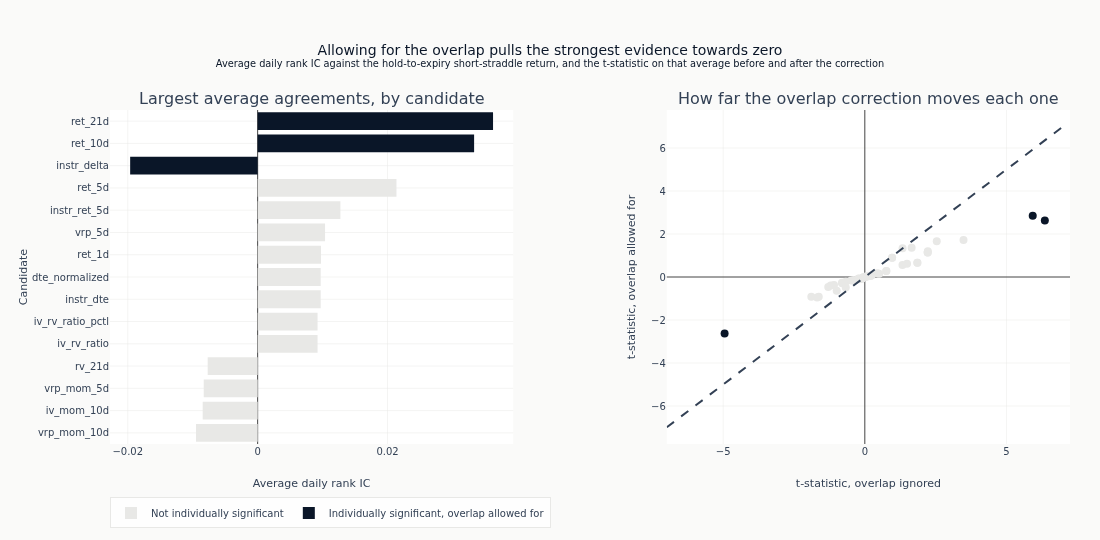

In [31]:
max_t = (
    max(
        float(eval_summary["naive_t"].abs().max() or 1.0),
        float(eval_summary["hac_t"].abs().max() or 1.0),
    )
    * 1.1
)
fig.add_trace(
    go.Scatter(
        x=[-max_t, max_t],
        y=[-max_t, max_t],
        mode="lines",
        line=dict(dash="dash", color=COLORS["neutral"]),
        showlegend=False,
    ),
    row=1,
    col=2,
)

fig.update_layout(
    template="ml4t",
    height=540,
    width=1100,
    title={
        "text": (
            "Allowing for the overlap pulls the strongest evidence towards zero"
            "<br><sup>Average daily rank IC against the hold-to-expiry short-straddle return, "
            "and the t-statistic on that average before and after the correction</sup>"
        )
    },
    margin=dict(l=110, r=30, t=110, b=60),
    legend=dict(orientation="h", y=-0.16, x=0),
)
fig.update_xaxes(title_text="Average daily rank IC", zeroline=True, row=1, col=1)
fig.update_xaxes(title_text="t-statistic, overlap ignored", row=1, col=2)
fig.update_yaxes(title_text="Candidate", row=1, col=1)
fig.update_yaxes(title_text="t-statistic, overlap allowed for", row=1, col=2)
show_plotly_with_alt(
    fig,
    "Two panels. On the left, a horizontal bar chart of the average daily rank IC by "
    "candidate, ordered by size, with only ret_21d, ret_10d and instr_delta shaded as "
    "individually significant once the overlap is allowed for and the other twelve left pale. "
    "On the right, a scatter of the t-statistic with the overlap ignored against the "
    "t-statistic with it allowed for, one point per candidate, with a dashed diagonal marking "
    "where the two would agree. Every point sits inside the diagonal, so each t-statistic "
    "shrinks towards zero; the three largest move the most, ret_21d from 6.0 to 2.4 and ret_10d "
    "from 5.7 to 2.7 on the positive side, instr_delta from -4.6 to -2.4 on the negative.",
)

The gap between what the two panels support is the point of the section. Some candidates
still stand out individually once the overlap is allowed for; whether any of them
clears the bar set by having asked the question of every candidate at once is a
separate question, and the answer is what the promotion rule in Section 7 acts on.

### How far ahead does the agreement reach?

Everything above is measured against one outcome, held for about a month. A quantity
whose agreement is concentrated at a few days and gone by ten cannot be traded at this
cadence, and one still reaching a month out could be traded less often and more
cheaply. Neither is visible from a single horizon, so the same measurement is repeated
against the two shorter unhedged outcomes `02_labels` also writes - the return over the
next five and the next ten sessions.

These are diagnostic only. No decision in Section 7 reads them, so measuring them does
not widen the set of tests the adjustment above has to cover. The traded outcome is
plotted at the holding period `setup.yaml` declares, which is where a one-month expiry
falls on average; its own horizon varies by a few sessions from name to name.

The right panel divides each average by the standard deviation of its own daily series.
That ratio says how large the average is against the variation it was drawn from, which
is what decides whether a longer horizon is genuinely more reliable or just measured
over a smoother series. The usual form of this ratio is taken across validation
periods, which two of them cannot support.

In [32]:
HORIZON_LABELS = {
    "fwd_ret_5d": int(_setup["labels"]["variant_buffers"]["fwd_ret_5d"].rstrip("D")),
    "fwd_ret_10d": int(_setup["labels"]["variant_buffers"]["fwd_ret_10d"].rstrip("D")),
    _primary_name: HOLD_SESSIONS,
}
session_grid = features[DATE_COL].unique().sort()

horizon_ic = {}
for label_name, horizon in sorted(HORIZON_LABELS.items(), key=lambda item: item[1]):
    if label_name == _primary_name:
        horizon_panel, horizon_col = eval_panel, primary_label_col
    else:
        horizon_labels = pl.read_parquet(CASE_DIR / "labels" / f"{label_name}.parquet")
        horizon_col = [
            c for c in horizon_labels.columns if c not in META_COLS and c != "instrument_id"
        ][0]
        horizon_panel = eval_panel.join(
            horizon_labels.select(JOIN_COLS + [horizon_col]), on=JOIN_COLS, how="inner"
        )
        exit_max = latest_exit_session(horizon_panel[DATE_COL], horizon, session_grid)
        if exit_max >= HOLDOUT_START:
            raise ValueError(f"A {label_name} position closing {exit_max} reaches the holdout")

    wide = daily_rank_ic(horizon_panel, horizon_col, leading_features)
    horizon_ic[horizon] = {
        feat: (
            float(wide[feat].mean()),
            float(wide[feat].mean() / wide[feat].std()) if wide[feat].std() else float("nan"),
        )
        for feat in leading_features
    }

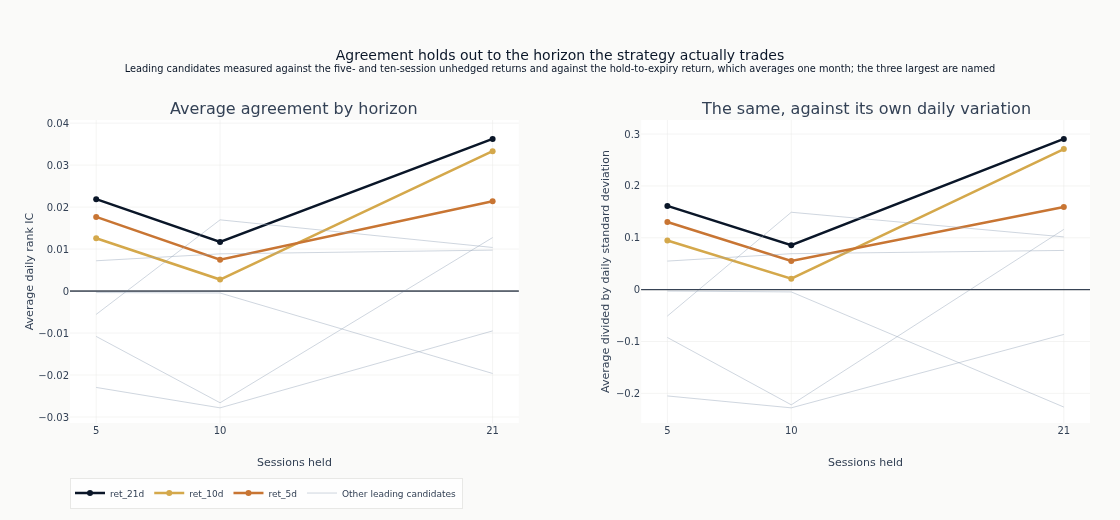

In [33]:
horizons = sorted(horizon_ic)
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        "Average agreement by horizon",
        "The same, against its own daily variation",
    ],
    horizontal_spacing=0.12,
)
# The three largest are named and given their own colour; the rest are drawn as one grey
# group, because ten distinguishable colours is not a legend anyone reads.
EMPHASIS_COLORS = [COLORS["blue"], COLORS["amber"], COLORS["copper"]]

for panel, index in [(1, 0), (2, 1)]:
    for rank, feat in enumerate(leading_features):
        emphasised = rank < len(EMPHASIS_COLORS)
        fig.add_trace(
            go.Scatter(
                x=horizons,
                y=[horizon_ic[h][feat][index] for h in horizons],
                mode="lines+markers" if emphasised else "lines",
                line=dict(
                    color=EMPHASIS_COLORS[rank] if emphasised else COLORS["recede"],
                    width=2.5 if emphasised else 1.0,
                ),
                marker=dict(size=6),
                opacity=1.0 if emphasised else 0.45,
                name=feat if emphasised else "Other leading candidates",
                legendgroup=feat if emphasised else "other",
                showlegend=panel == 1 and (emphasised or rank == len(EMPHASIS_COLORS)),
                hovertext=feat,
            ),
            row=1,
            col=panel,
        )
    fig.add_hline(y=0, line=dict(color=COLORS["neutral"], width=1), row=1, col=panel)

fig.update_layout(
    template="ml4t",
    height=520,
    width=1120,
    title={
        "text": (
            "Agreement holds out to the horizon the strategy actually trades"
            "<br><sup>Leading candidates measured against the five- and ten-session unhedged "
            "returns and against the hold-to-expiry return, which averages one month; the "
            "three largest are named</sup>"
        )
    },
    margin=dict(l=70, r=30, t=120, b=60),
    legend=dict(orientation="h", y=-0.18, x=0, font=dict(size=9)),
)
fig.update_xaxes(title_text="Sessions held", tickvals=horizons)
fig.update_yaxes(title_text="Average daily rank IC", row=1, col=1)
fig.update_yaxes(title_text="Average divided by daily standard deviation", row=1, col=2)
show_plotly_with_alt(
    fig,
    "Two panels sharing a horizontal axis of sessions held, at 5, 10 and 21. On the left the "
    "average daily rank IC and on the right the same average divided by its daily standard "
    "deviation. ret_21d, ret_10d and ret_5d are drawn as named coloured lines and the other "
    "leading candidates as pale grey lines. All three named lines dip at 10 sessions and rise "
    "to their highest value at 21, ret_21d reaching about 0.035 on the left and about 0.28 on "
    "the right. The grey lines mostly sit below zero and do not share that shape, so agreement "
    "holds out to the horizon the strategy actually trades for the named three.",
)

## 4. Is the relationship one a ranking strategy can use?

A correlation can be produced by a handful of extreme values while the middle of the
distribution says nothing. That matters here because the strategy does not act on the
correlation, it acts on the ordering: it sells the straddles at one end of the ranking.
So the question is whether the outcome improves *steadily* as the candidate rises,
which is what makes an ordering worth acting on and what a linear model can represent.

Within each trading day, sort the names by the candidate and cut them into five equal
groups. Within the day, because the strategy chooses between names available on the
same day; cutting the pooled sample would let one day's distribution set another day's
boundaries and would mix movement over time into a diagnostic whose companion
measurement is purely across names.

Then average the outcome inside each group on that day, average those daily figures
across days, and score how close the resulting five averages are to a straight climb or
fall. Every day carries the same weight in that second average, because the strategy
trades a fixed handful of names each day rather than a share of the cross-section.
Averaging every name-day in a group in one pass would let the widest days decide the
shape. A day enters here on the same terms it enters the correlation on.

In [34]:
N_QUANTILES = 5
top_features_for_shape = eval_summary.filter(pl.col("fdr_sig").fill_null(False))[
    "feature"
].to_list()[:15]
if not top_features_for_shape:
    top_features_for_shape = eval_summary.head(10)["feature"].to_list()

monotonicity_scores = {}
quantile_spreads = {}

for feat in top_features_for_shape:
    profile = quantile_profile(
        eval_panel,
        feat,
        primary_label_col,
        date_col=DATE_COL,
        n_quantiles=N_QUANTILES,
        min_cross_section=MIN_CROSS_SECTION,
    )
    if profile is None:
        continue
    quantile_spreads[feat] = {"q_means": profile.means, "spread": profile.spread}
    monotonicity_scores[feat] = profile.monotonicity

MONOTONE_MIN = 0.8  # how close to a straight climb or fall the five averages must sit

n_monotone = sum(1 for s in monotonicity_scores.values() if abs(s) >= MONOTONE_MIN)
print(f"{n_monotone} of {len(monotonicity_scores)} scored candidates reach {MONOTONE_MIN}")

6 of 8 scored candidates reach 0.8


One panel per candidate, all on the same vertical scale so that a shallow profile
cannot be rescaled into a steep-looking one. Every candidate the diagnostic scored is
drawn rather than a selection of them, so the count above can be checked against the
chart. The bars darken from the lowest group to the highest, which orders the groups and
says nothing about which end is preferable.

The label is written from the seller's side throughout - `02_labels` defines it as the
premium collected less what the position costs to close, over the premium collected - so
a positive value is a profitable short straddle and a higher average is the better
outcome. Nearly every group here averages negative, which is the sample rather than the
convention: these two validation periods contain the volatility of early 2020.

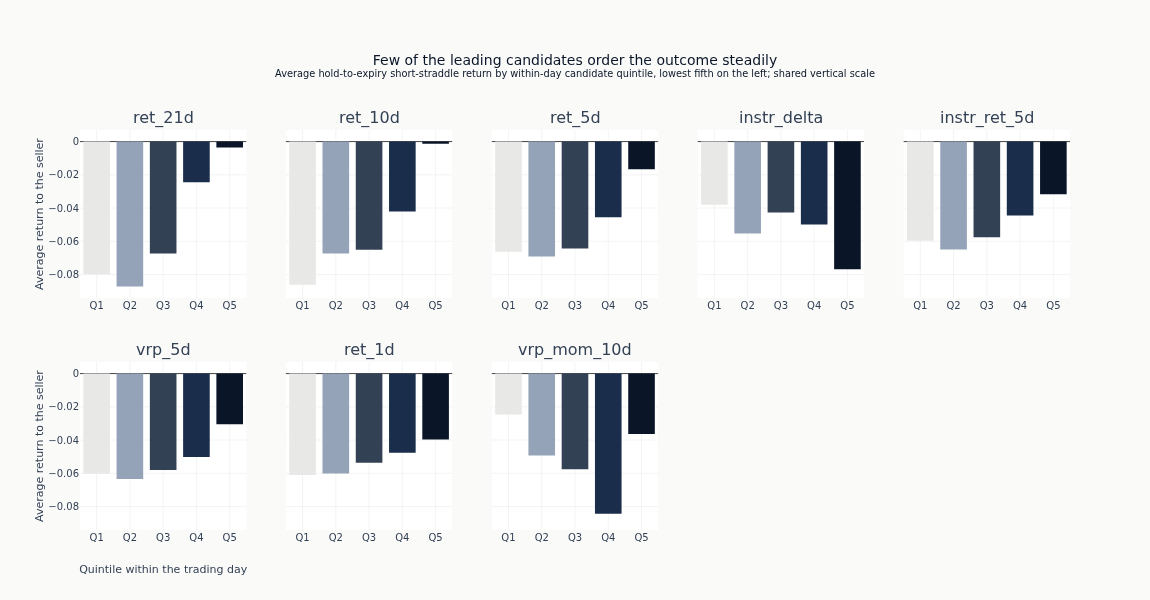

In [35]:
if quantile_spreads:
    feats_to_show = list(quantile_spreads.keys())
    n_show = len(feats_to_show)
    n_cols = min(5, n_show)
    n_rows_fig = (n_show + n_cols - 1) // n_cols
    quintile_shades = [
        COLORS["silver_muted"],
        COLORS["recede"],
        COLORS["neutral"],
        COLORS["slate"],
        COLORS["blue"],
    ]
    # One vertical scale across the panels, so a shallow profile is not rescaled into a
    # steep-looking one, and it always includes zero, because a bar read against any
    # other baseline is a bar whose length means nothing.
    q_low = min(0.0, min(min(q["q_means"]) for q in quantile_spreads.values()))
    q_high = max(0.0, max(max(q["q_means"]) for q in quantile_spreads.values()))
    q_pad = 0.08 * (q_high - q_low or 1.0)

    fig = make_subplots(
        rows=n_rows_fig,
        cols=n_cols,
        subplot_titles=feats_to_show,
        shared_yaxes=True,
        vertical_spacing=0.16,
    )
    for idx, feat in enumerate(feats_to_show):
        r, c = divmod(idx, n_cols)
        q_means = quantile_spreads[feat]["q_means"]
        fig.add_trace(
            go.Bar(
                x=[f"Q{i + 1}" for i in range(len(q_means))],
                y=q_means,
                marker_color=quintile_shades[: len(q_means)],
                showlegend=False,
            ),
            row=r + 1,
            col=c + 1,
        )
    fig.update_layout(
        template="ml4t",
        height=300 * n_rows_fig,
        width=1150,
        title={
            "text": (
                "Few of the leading candidates order the outcome steadily"
                "<br><sup>Average hold-to-expiry short-straddle return by within-day candidate "
                "quintile, lowest fifth on the left; shared vertical scale</sup>"
            )
        },
        margin=dict(t=130, b=70),
    )
    fig.update_yaxes(range=[q_low - q_pad, q_high + q_pad])
    fig.update_xaxes(title_text="Quintile within the trading day", row=n_rows_fig, col=1)
    for row in range(1, n_rows_fig + 1):
        fig.update_yaxes(title_text="Average return to the seller", row=row, col=1)
    show_plotly_with_alt(
        fig,
        "Grid of small bar charts, one per leading candidate, each showing the average "
        "hold-to-expiry short-straddle return by within-day candidate quintile from Q1 on the "
        "left to Q5 on the right, on a shared vertical scale where every bar is negative. Only "
        "ret_10d orders the outcome without a reversal, rising from about -0.098 at Q1 to about "
        "-0.016 at Q5; ret_21d has the same shape but its first two bars are level, at about "
        "-0.095. instr_delta runs the other way, least negative at Q1 and most negative at Q5, "
        "but not steadily. The other seven reverse somewhere in the interior: ret_5d, "
        "instr_ret_5d, iv_rv_ratio and iv_rv_ratio_pctl are most negative at Q2, iv_mom_10d at "
        "Q3, and vrp_mom_10d and vrp_mom_5d at Q4, so their quintile ordering does not carry "
        "through.",
    )

## 5. Which candidates are the same evidence twice?

Every measurement so far has treated each candidate as if it were the only one. Many of
them are not independent of each other. Several read the same implied volatility at
different lookbacks; a percentile of a quantity is a re-expression of that quantity, and
a rank correlation cannot tell the two apart at all. When two candidates are near copies,
two promotions are one piece of evidence, and a count of promotions read as a count of
findings overstates what the screen found.

This section measures how far that goes. It does not drop anything: which member of a
redundant group to keep is a question about the whole feature set at once, which is
what the modelling chapters do with regularisation and what a univariate screen has no
standing to decide.

The correlation is taken over a sample of the trading days rather than all of them,
spaced evenly through the period, because it is a description of the feature set rather
than an estimate anything depends on.

In [36]:
corr_features = [f for f in evaluable_features if f in ic_results]
sample_step = max(1, n_dates // 200)
sample_dates = eval_panel[DATE_COL].unique().sort().to_list()[::sample_step]
corr_data = (
    eval_panel.filter(pl.col(DATE_COL).is_in(sample_dates)).select(corr_features).to_pandas()
)
corr_matrix = corr_data.corr(method="spearman")

high_corr_pairs = [
    (corr_matrix.columns[i], corr_matrix.columns[j], round(corr_matrix.iloc[i, j], 3))
    for i in range(len(corr_matrix.columns))
    for j in range(i + 1, len(corr_matrix.columns))
    if abs(corr_matrix.iloc[i, j]) > REDUNDANCY_CUT
]

print(f"{len(high_corr_pairs)} candidate pairs correlate above {REDUNDANCY_CUT} in absolute value")
display(
    pl.DataFrame(
        sorted(high_corr_pairs, key=lambda x: -abs(x[2]))[:10],
        schema=["candidate", "paired with", "rank correlation"],
        orient="row",
    )
)

91 candidate pairs correlate above 0.7 in absolute value


candidate,paired with,rank correlation
str,str,f64
"""instr_dte""","""dte_normalized""",1.0
"""iv_atm""","""call_iv""",0.999
"""iv_atm""","""put_iv""",0.999
"""call_iv""","""put_iv""",0.994
"""instr_gamma""","""instr_theta""",0.993
"""instr_pct_of_S""","""iv_atm""",0.992
"""instr_pct_of_S""","""call_iv""",0.99
"""instr_pct_of_S""","""put_iv""",0.99
"""theta_vega_ratio""","""iv_atm""",-0.973


The map below is restricted to the leading candidates, because at fifty a full matrix
has unreadable labels and is mostly empty space, and to one triangle, because a
correlation matrix is symmetric and drawing both halves says everything twice. The rows
keep the ranking used everywhere else in the notebook - largest average agreement first
- so a block of colour is a group of near-copies that also rank near each other.

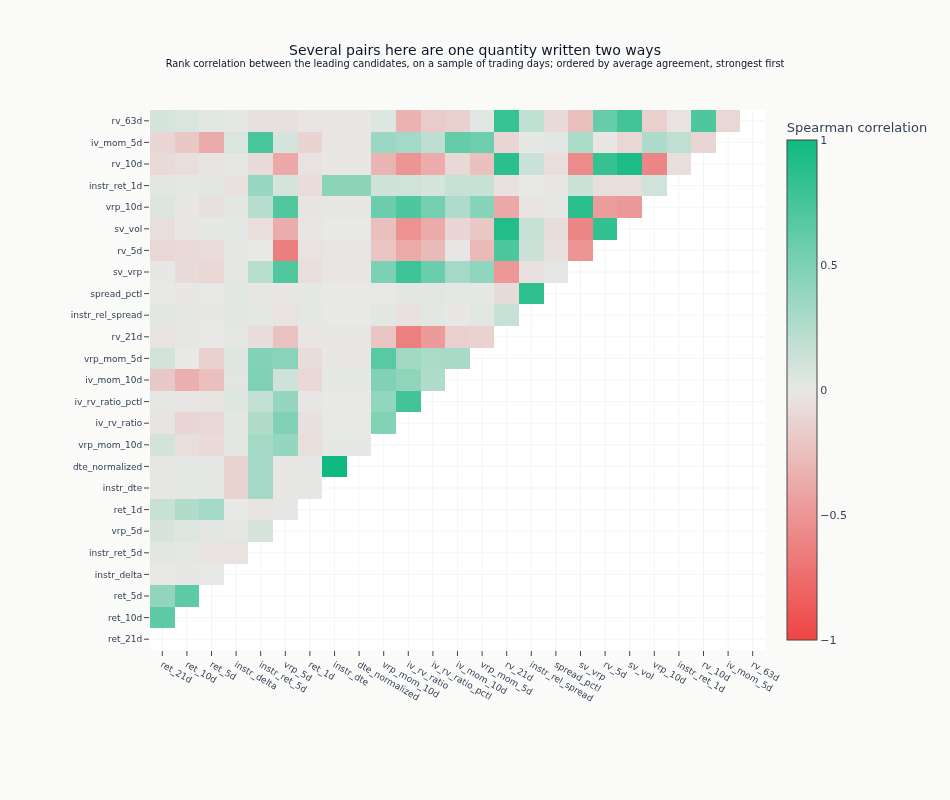

In [37]:
_div = style.ml4t_diverging()
ml4t_corr_scale = [[0.0, _div[0]], [0.5, _div[1]], [1.0, _div[2]]]
corr_plot_features = eval_summary.head(min(25, len(eval_summary)))["feature"].to_list()
corr_plot = corr_matrix.loc[corr_plot_features, corr_plot_features]
corr_display = corr_plot.mask(np.triu(np.ones(corr_plot.shape, dtype=bool)))
fig = go.Figure(
    data=go.Heatmap(
        z=corr_display.values,
        x=corr_plot.columns.tolist(),
        y=corr_plot.columns.tolist(),
        colorscale=ml4t_corr_scale,
        zmid=0,
        zmin=-1,
        zmax=1,
        colorbar=dict(title="Spearman correlation"),
    )
)
fig.update_layout(
    title={
        "text": (
            "Several pairs here are one quantity written two ways"
            "<br><sup>Rank correlation between the leading candidates, on a sample of trading "
            "days; ordered by average agreement, strongest first</sup>"
        )
    },
    template="ml4t",
    height=800,
    width=950,
    margin=dict(l=150, r=50, t=110, b=150),
)
fig.update_xaxes(tickfont=dict(size=9))
fig.update_yaxes(tickfont=dict(size=9))
show_plotly_with_alt(
    fig,
    "Lower-triangular heatmap of the Spearman rank correlation between 25 candidates on a "
    "sample of trading days, ordered by average agreement with the strongest first, on a "
    "red-to-green scale from -1 to +1. Three quarters of the 300 off-diagonal cells are paler "
    "than 0.3 either way. The green ones mark pairs that are close to one quantity written "
    "twice: instr_dte with dte_normalized at exactly 1.00, rv_10d and rv_21d with sv_vol at "
    "0.94 and 0.92, instr_rel_spread with spread_pctl and sv_vrp with vrp_10d both at 0.86, and "
    "iv_rv_ratio with iv_rv_ratio_pctl at 0.78. The strongest red cells set realized volatility "
    "against the variance-risk-premium terms - rv_5d with vrp_5d and rv_21d with iv_rv_ratio "
    "both at -0.63, sv_vrp with sv_vol at -0.58 - so those pairs move opposite each other "
    "rather than independently.",
)

### The same evidence, grouped by family

Rolling the candidates up to the families declared in `config/setup.yaml` says which
lines of reasoning the screen found anything in, rather than which columns. The average
absolute agreement per family is a crude summary and is not a decision - a family of
one strong candidate and five weak ones averages to the same place as six mediocre
ones - but it is the level at which a reader decides what to build more of.

In [38]:
family_ic = {}
fdr_sig_set = set(eval_summary.filter(pl.col("fdr_sig").fill_null(False))["feature"].to_list())

for feat in ic_results:
    fam = families.get(feat, "other")
    family_ic.setdefault(fam, []).append(
        {"feature": feat, "ic": ic_results[feat]["mean_ic"], "fdr_sig": feat in fdr_sig_set}
    )

family_summary = {}
for fam, feats in sorted(family_ic.items()):
    ics = [f["ic"] for f in feats if f["ic"] is not None]
    family_summary[fam] = {
        "measured": len(feats),
        "mean |agreement|": round(float(np.mean([abs(ic) for ic in ics])), 4) if ics else 0.0,
        "mean agreement": round(float(np.mean(ics)), 4) if ics else 0.0,
        "family-wide discoveries": sum(1 for f in feats if f["fdr_sig"]),
    }

fam_df = pl.DataFrame(
    [{"family": fam, **stats} for fam, stats in family_summary.items()],
    schema={
        "family": pl.String,
        "measured": pl.Int64,
        "mean |agreement|": pl.Float64,
        "mean agreement": pl.Float64,
        "family-wide discoveries": pl.Int64,
    },
).sort("mean |agreement|", descending=True)
display(fam_df)

family,measured,mean |agreement|,mean agreement,family-wide discoveries
str,i64,f64,f64,i64
"""underlying""",5,0.0202,0.02,0
"""stochastic_volatility""",2,0.0074,0.0002,0
"""instrument_state""",12,0.0059,0.0026,0
"""realized_volatility""",5,0.0056,-0.0056,0
"""cross_sectional""",4,0.0055,0.0055,0
"""variance_risk_premium""",10,0.0054,0.0005,0
"""surface_dynamics""",4,0.004,-0.0029,0
"""surface_level""",4,0.0017,0.0005,0
"""garch_volatility""",2,0.0011,-0.0011,0


## 6. How much of it is about volatility rather than direction?

A short straddle loses money when the underlying moves a long way in either direction,
so its return depends both on how volatile the name turns out to be and on where it
happens to go. A candidate that ranks names by their coming direction would show up in
Section 2 exactly like one that ranks them by their coming volatility.

The second label separates the two. It is the same position with the directional
exposure hedged away - a stock position adjusted daily to offset the option's
sensitivity to the underlying's price - so what is left is close to the volatility
outcome alone. It also closes after ten sessions rather than at expiry, because that is
the horizon the hedged variant was built at. Both things change at once, which is why
this is a sensitivity check and not an attribution: a candidate that moves between the
two panels has changed under a different hedge *and* a different horizon, and this
comparison cannot say which.

The evaluation frame is joined to the second label rather than rebuilt around it, so
the comparison runs on the same rows Section 2 measured.

In [39]:
dh_eval = eval_panel.join(
    secondary_label_df.select(JOIN_COLS + [secondary_label_col]),
    on=JOIN_COLS,
    how="inner",
)

The holdout boundary was applied to the day the straddle expires, and this second
position closes on a different day. It happens to close earlier in every case, because
every expiry in the panel is further out than ten sessions - but that is a property of
the data rather than something the code guarantees, so it is checked here. A shorter
expiry would otherwise open a hole in this section without touching anything above.

In [40]:
SECONDARY_HORIZON_SESSIONS = int(_setup["labels"]["variant_buffers"][_secondary_name].rstrip("D"))
dh_endpoint_max = latest_exit_session(dh_eval[DATE_COL], SECONDARY_HORIZON_SESSIONS, session_grid)
if dh_endpoint_max >= HOLDOUT_START:
    raise ValueError(f"A delta-hedged position closing {dh_endpoint_max} reaches the holdout")

The daily measurement is the same one Section 2 makes, against the other label and with
the same per-candidate floor on the cross-section.

In [41]:
dh_ic_wide = daily_rank_ic(dh_eval, secondary_label_col, cs_features)

dh_ic_results = {}
for feat in cs_features:
    ic_df = (
        dh_ic_wide.select([DATE_COL, pl.col(feat).alias("ic")])
        .drop_nulls(subset=["ic"])
        .filter(pl.col("ic").is_finite())
    )
    if len(ic_df) < MIN_IC_DAYS:
        continue
    dh_ic_results[feat] = float(ic_df["ic"].mean())

Every candidate with both measurements is plotted. A point on the diagonal agreed with
both outcome definitions equally; one on the vertical axis carries information about
the hedged outcome and none about the traded one. The three underlying-return horizons
and the option's own directional sensitivity are labelled, because they are the
candidates for which the distinction is the point.

In [42]:
dh_rows = []
for feat in cs_features:
    if feat in ic_results and feat in dh_ic_results:
        dh_rows.append(
            {
                "feature": feat,
                "ic_unhedged": round(ic_results[feat]["mean_ic"], 4),
                "ic_hedged": round(dh_ic_results[feat], 4),
            }
        )

if dh_rows:
    dh_df = pl.DataFrame(dh_rows).sort(pl.col("ic_unhedged").abs(), descending=True)
    highlighted = ["ret_5d", "ret_10d", "ret_21d", "instr_delta"]
    background = dh_df.filter(~pl.col("feature").is_in(highlighted))
    foreground = dh_df.filter(pl.col("feature").is_in(highlighted))

    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=background["ic_unhedged"].to_list(),
            y=background["ic_hedged"].to_list(),
            mode="markers",
            marker=dict(color=COLORS["silver_muted"], size=7),
            text=background["feature"].to_list(),
            name="Other candidates",
        )
    )
    fig.add_trace(
        go.Scatter(
            x=foreground["ic_unhedged"].to_list(),
            y=foreground["ic_hedged"].to_list(),
            mode="markers+text",
            marker=dict(color=COLORS["blue"], size=9),
            text=foreground["feature"].to_list(),
            textposition="top center",
            name="Underlying return and option delta",
        )
    )

Both axes share one symmetric scale, so a point's distance from the diagonal is
readable as a difference rather than as an artefact of two ranges.

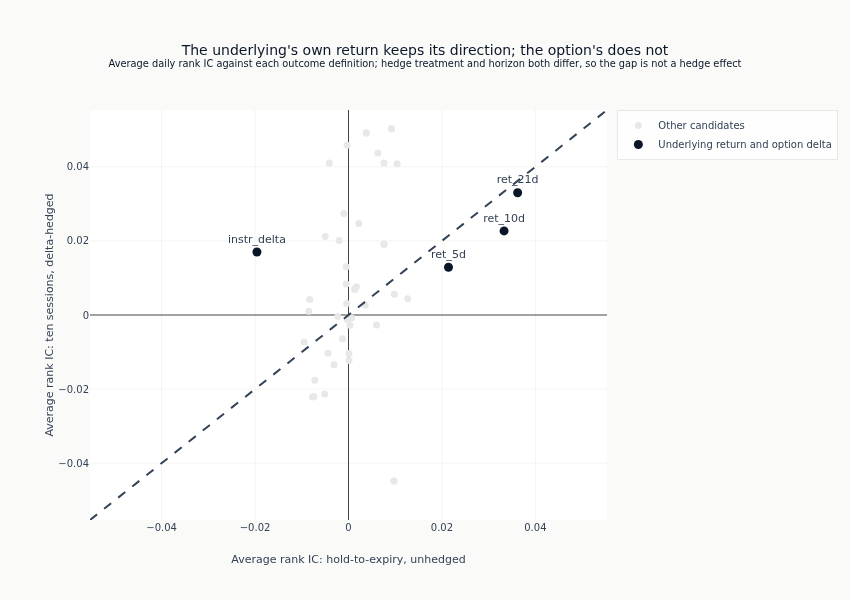

In [43]:
if dh_rows:
    label_limit = float(max(dh_df["ic_unhedged"].abs().max(), dh_df["ic_hedged"].abs().max()) * 1.1)
    fig.add_trace(
        go.Scatter(
            x=[-label_limit, label_limit],
            y=[-label_limit, label_limit],
            mode="lines",
            line=dict(color=COLORS["neutral"], dash="dash"),
            showlegend=False,
        )
    )
    fig.update_layout(
        title={
            "text": (
                "The underlying's own return keeps its direction; the option's does not"
                "<br><sup>Average daily rank IC against each outcome definition; hedge "
                "treatment and horizon both differ, so the gap is not a hedge effect</sup>"
            )
        },
        template="ml4t",
        width=850,
        height=600,
        xaxis_title="Average rank IC: hold-to-expiry, unhedged",
        yaxis_title="Average rank IC: ten sessions, delta-hedged",
        xaxis_range=[-label_limit, label_limit],
        yaxis_range=[-label_limit, label_limit],
        margin=dict(l=90, r=30, t=110, b=80),
    )
    show_plotly_with_alt(
        fig,
        "Scatter of the average rank IC against the ten-session delta-hedged outcome on the "
        "vertical axis versus the hold-to-expiry unhedged outcome on the horizontal, one point "
        "per candidate, with a dashed diagonal marking where the two would agree. The three "
        "underlying-return candidates are labelled and sit close to the diagonal on the "
        "positive side, ret_21d the highest of them at 0.035 unhedged and 0.038 hedged, so "
        "their direction survives both outcome definitions. instr_delta is labelled in the "
        "upper-left quadrant at about -0.018 unhedged and +0.017 hedged, changing sign between "
        "them. Several unlabelled points sit far above the diagonal - the variance-risk-premium "
        "and iv_rv_ratio columns reach 0.04 to 0.05 hedged on an unhedged reading near 0.01. "
        "Hedge treatment and horizon both differ between the axes, so the gap is not a hedge "
        "effect on its own.",
    )

## 7. The decision each candidate earned

Each candidate is sorted into one of the three decisions Chapter 7 defines. The
thresholds named below are the configured constants from the top of the notebook.

| Decision | What it takes |
|---|---|
| **PROCEED** | Either the family-wide adjustment kept it at `FDR_ALPHA`, or it was positive in at least `SIGN_CONSISTENCY_MIN` of the validation periods and reached `IC_THRESHOLD` in absolute average agreement. |
| **STOP** | It failed a Section 1 screen - observed on less than `COVERAGE_MIN` of rows, or repeating its previous value on more than `STALENESS_MAX` of them. |
| **REVISE** | Everything else: it is carried into the modelling chapters without a standalone result behind it. |

The two routes to PROCEED are not the same kind of claim, and the ledger's `note`
column records which one a candidate took. The first is a test whose multiplicity has
been paid for. The second is an **exploration** route: it exists because a family-wide
adjustment over fifty candidates measured on two periods will often keep nothing, and a
screen that hands the modelling chapters an empty list has not helped them. A candidate
promoted through it has been found interesting, not confirmed.

Read the word *positive* in that second route literally. It asks for periods that agree
with each other **and** point up, so a candidate that reliably ranks names inversely -
low value, high straddle return - cannot take it however reliable it is. Such a
candidate reaches the modelling chapters as REVISE, and the per-period figure in
Section 2 is where a reader sees the evidence the rule did not act on.

In [44]:
triage = {}
for feat in all_feature_cols:
    if not readable[feat]:
        triage[feat] = ("STOP", "correctness_fail")
        continue

    if feat in date_level_features:
        triage[feat] = ("REVISE", "date_level_feature")
        continue

    if feat not in ic_results:
        triage[feat] = ("REVISE", "insufficient_data")
        continue

    is_fdr_sig = feat in fdr_sig_set
    sign_con = fold_stats.get(feat, {}).get("sign_consistency", 0)
    abs_ic = abs(ic_results[feat]["mean_ic"])

    if feat in fold_constant_features:
        if is_fdr_sig:
            triage[feat] = ("PROCEED", "fdr_significant_fold_constant")
        else:
            triage[feat] = ("REVISE", "fold_constant")
    elif is_fdr_sig:
        triage[feat] = ("PROCEED", "fdr_significant")
    elif sign_con >= SIGN_CONSISTENCY_MIN and abs_ic >= IC_THRESHOLD:
        triage[feat] = ("PROCEED", "stable_and_above_threshold")
    else:
        triage[feat] = ("REVISE", "not_significant_standalone")

### The ledger

One row per candidate, carrying the decision and every measurement that fed it, so that
the decision can be re-derived from the file rather than taken on trust. The Chapter 20
notebook reads these files for all nine case studies and builds one table out of them.

In [45]:
ledger_rows = []
for feat in all_feature_cols:
    decision, note = triage[feat]
    row = {
        "feature": feat,
        "family": families.get(feat, "other"),
        "source": "temporal" if feat in temporal_cols else "financial",
        "ic_mean": ic_results.get(feat, {}).get("mean_ic"),
        "hac_t": ic_results.get(feat, {}).get("t_stat"),
        "hac_p": ic_results.get(feat, {}).get("p_value"),
        "fdr_p": None,
        "fdr_sig": False,
        "sign_consistency": fold_stats.get(feat, {}).get("sign_consistency"),
        "worst_fold_ic": fold_stats.get(feat, {}).get("worst_fold_ic"),
        "monotonicity": monotonicity_scores.get(feat),
        "coverage": coverage[feat],
        "staleness": staleness[feat],
        "decision": decision,
        "note": note,
    }
    match = eval_summary.filter(pl.col("feature") == feat)
    if len(match) > 0:
        row["fdr_p"] = float(match["fdr_p"][0])
        row["fdr_sig"] = bool(match["fdr_sig"][0])
    ledger_rows.append(row)

triage_ledger = pl.DataFrame(ledger_rows)
triage_ledger.write_parquet(EVAL_DIR / "triage_ledger.parquet")
print("Wrote evaluation/triage_ledger.parquet")
display(triage_ledger.group_by("decision").len().sort("decision"))

Wrote evaluation/triage_ledger.parquet


decision,len
str,u32
"""PROCEED""",6
"""REVISE""",42
"""STOP""",3


The daily series behind every average is written alongside it, one long frame keyed by
candidate and date. It is the evidence the ledger's summary statistics condense, and it
is what Section 2's first figure was drawn from.

In [46]:
ic_ts_frames = [
    ts.with_columns(pl.lit(feat).alias("feature")) for feat, ts in ic_timeseries.items()
]

if ic_ts_frames:
    ic_ts_all = pl.concat(ic_ts_frames)
    ic_ts_all.write_parquet(EVAL_DIR / "ic_timeseries.parquet")
    print(f"Wrote evaluation/ic_timeseries.parquet ({len(ic_ts_all):,} rows)")

Wrote evaluation/ic_timeseries.parquet (22,436 rows)


The candidates that reached PROCEED, with the evidence and the route each took.

In [47]:
proceed_features = sorted(f for f, (d, _) in triage.items() if d == "PROCEED")
revise_features = [f for f, (d, _) in triage.items() if d == "REVISE"]
stop_features = [f for f, (d, _) in triage.items() if d == "STOP"]

display(
    triage_ledger.filter(pl.col("decision") == "PROCEED")
    .select(
        "feature",
        "family",
        pl.col("ic_mean").round(4),
        pl.col("hac_t").round(2),
        pl.col("fdr_p").round(3),
        "sign_consistency",
        "note",
    )
    .sort(pl.col("ic_mean").abs(), descending=True)
)

feature,family,ic_mean,hac_t,fdr_p,sign_consistency,note
str,str,f64,f64,f64,f64,str
"""ret_21d""","""underlying""",0.0362,2.63,0.141,1.0,"""stable_and_above_threshold"""
"""ret_10d""","""underlying""",0.0333,2.84,0.141,1.0,"""stable_and_above_threshold"""
"""ret_5d""","""underlying""",0.0214,1.72,0.927,1.0,"""stable_and_above_threshold"""
"""instr_delta""","""instrument_state""",-0.0196,-2.63,0.141,1.0,"""stable_and_above_threshold"""
"""instr_ret_5d""","""instrument_state""",0.0127,1.67,0.927,1.0,"""stable_and_above_threshold"""
"""vrp_5d""","""variance_risk_premium""",0.0104,1.2,0.996,1.0,"""stable_and_above_threshold"""


**Triage.** The ledger records 7 PROCEED, 42 REVISE and 2 STOP over the 51 candidates.
Both STOP decisions are the quality flags, and they fail on staleness rather than on
coverage: they are present on every row and identical on every row, so there is nothing
in them to rank by. All 7 promotions came through the exploration route, because
nothing cleared the family-wide adjustment - three horizons of the underlying's return,
the 5-session return on the straddle itself, and three variance-premium quantities,
each positive in both validation periods and reaching `IC_THRESHOLD`.

Two of the seven, `iv_rv_ratio` and its within-day percentile, carry the same average
agreement to four decimals, because ranking a quantity's percentile is ranking the
quantity: the promoted set is seven columns and fewer than seven pieces of evidence.
`instr_delta` is the case the promotion rule cannot reach. It carries the fourth-largest
average agreement, it is one of the three that clear the overlap-aware threshold on
their own, and it is negative in both periods - so it reaches the modelling chapters as
REVISE.

## Key Takeaways

1. **Rank the assets available on a day, not the whole sample at once.** A strategy
   that chooses between the names quoted on a Friday is helped by a quantity that
   orders those names correctly, and a correlation computed over every name and every
   date at once measures something else - partly how the market moved over time. Every
   measurement here is taken within one trading day and then averaged over days.

2. **Say how long a position lives before quoting any significance.** Positions opened
   on consecutive days overlap, so consecutive daily measurements are not independent
   draws and the plain error bar is too narrow. Deriving the correction's reach from
   the configured holding period rather than typing a lag is what keeps that link
   visible when the holding period changes.

3. **State what was searched before reading a p-value.** The count of candidates tested
   and the label they were tested against are what make a significance claim
   interpretable. Anything measured for diagnosis rather than for a decision is said to
   be so, or the searched set silently grows.

4. **A count of promotions is not a count of findings.** The screen is univariate, so a
   quantity and a monotone transform of it are promoted twice for one piece of
   evidence, and a rank correlation cannot distinguish them at all. Section 5 is where
   that is visible; deciding which member of a redundant group to keep needs the whole
   feature set at once, which is what the modelling chapters do.

5. **A screen that promotes nothing has not necessarily failed, and one that promotes
   on stability has not confirmed anything.** Recording which route a candidate took
   keeps a reader from reading the two as one number.

**Known limitations.** The screen is univariate throughout: a quantity that carries
information only in combination with another is invisible to it, and nothing here can
be read as a statement about a model built on several of them. It measures association
with an outcome and says nothing about what is left of that association once the cost
of trading options is paid, which is what Chapters 16 to 18 measure. Two validation
periods are enough to see a direction change and not enough to characterise how stable
a relationship is. And the second promotion route's threshold is a judgment about what is
worth carrying forward, not an inference from the data.

**Next**: [`06_linear`](06_linear.ipynb) fits penalised linear models to the whole
feature panel and does not read this ledger; the promotions here are a reading order,
not an input to it. The Chapter 20 notebook
([`02_feature_evaluation`](../../20_strategy_synthesis/02_feature_evaluation.ipynb))
does read it, for all nine case studies at once, and builds its cross-case table out of
them.